# <b> SMARTS -  Syncronus Multi Agent Real-Time Transit Scheduler</b>
**SMARTS** addresses a critical urban sustainability challenge: how to dynamically schedule public transit vehicles across diverse and unseen network topologies using a real-time data with a single generalized AI model.

Transit scheduling is inherently a spatial AI problem. Decisions depend on the geographic layout of stops, routes, and demand patterns distributed across space and time. Traditional approaches require retraining for each new transit system. SMARTS overcomes this by training a GNN-Transformer agent that generalizes across topologies it has never seen, enabling zero-shot deployment on new transit networks.

**Why this matters:** Efficient public transit directly impacts urban mobility, equity, emissions, and energy use; core sustainability challenges. A model that generalizes without retraining is immediately deployable in resource-constrained transit authorities worldwide. Futher a model like that can be used for downstream task/ transfer learning

This notebook uses two main components a `Realistic Tranist Simulator` and a `Scheduler`. The transit simulator is available in the `transit_system.py`. There are multiple type of scheduler in this study which are listed below:

1. RL based:
    * GNN-Transformer
    * DNN
2. Heuristics
3. Fixed Headway

The logic for schedulers are given in file `agent.py`. This study uses `GeoAI` kernel

<img width="685" height="512" alt="image" src="https://github.com/user-attachments/assets/81576ee7-da3e-4156-a221-2f1f3c4fd2b5" />   <img width="685" height="512" alt="image" src="https://github.com/user-attachments/assets/2c65da63-babd-42fc-b0ce-f293b78cb978" />


In [ ]:
# !rm -r -f IGUIDE2026-SMARTS/
# !git clone https://github.com/eco-trans/IGUIDE2026-SMARTS.git
# !cp IGUIDE2026-SMARTS/transit_system_config.json transit_system_config.json
# !cp -v IGUIDE2026-SMARTS/*.py .
# !cp -v IGUIDE2026-SMARTS/logs/*.csv logs/

In [ ]:
%pip install gymnasium
%pip install torch_geometric

In [1]:
import numpy as np
import pandas as pd
import torch
from env import TransitNetworkEnv
from agent import Model, collect_rollout, SimpleDNNAgent, fixed_policy
import matplotlib.pyplot as plt
import seaborn as sns
from time import time
import pickle as pkl

import warnings
warnings.filterwarnings(action='ignore', message='Mean of empty slice')


c:\Users\muk0003\AppData\Local\miniconda3\envs\iguide\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
%pip install onedrivedownloader
from onedrivedownloader import download
url = "https://tigermailauburn-my.sharepoint.com/:u:/g/personal/muk0003_auburn_edu/IQADaiXSPgIYQ48uzMbAFzKfATf8KXoB8LKd9_EOMPCshhQ?e=rUVIiz"
download(url, filename="file.zip")

100%|██████████| 3.10G/3.10G [04:00<00:00, 12.9MiB/s]


Unzipping file...


Extracting files: 100%|██████████| 22/22 [00:05<00:00,  3.97it/s]


''

## <b>Testing Transit Systems</b>

The main goal of this study is to built a transit scheduler that can generalize across transit systems without needing a finetuning. To verify our hypothesis we held some of the Transit systems provided below during the training of SMARTS. However we trained DNN and Simulated Anealing (SA) schedlers specifically for these transit systems. We trainined a seperate DNN and SA schedulers for each of these testing topologies. 

The question was to see if our SMARTS can outsmart the other shcedulres without ever seeing those systems.

The transit environments used in this study are procedurally generated using configurable seeds, ensuring diversity in network topology, passenger demand patterns, and route structures. Each environment instance represents a unique synthetic transit system with:

- **Variable graph topology** (nodes = stops, edges = routes)
- **Stochastic passenger arrival/departure patterns** modeled over an 18-hour service horizon
- **Configurable parameters** via `transit_system_config.json` for reproducibility

All environments are instantiated through `TransitNetworkEnv`, which wraps the simulation engine in a standard [Gymnasium](https://gymnasium.farama.org/) interface — making the data pipeline immediately compatible with standard RL and ML frameworks.

**Held-out test systems:** 9 transit topologies (seeds listed below) were withheld entirely from training to evaluate zero-shot generalization.

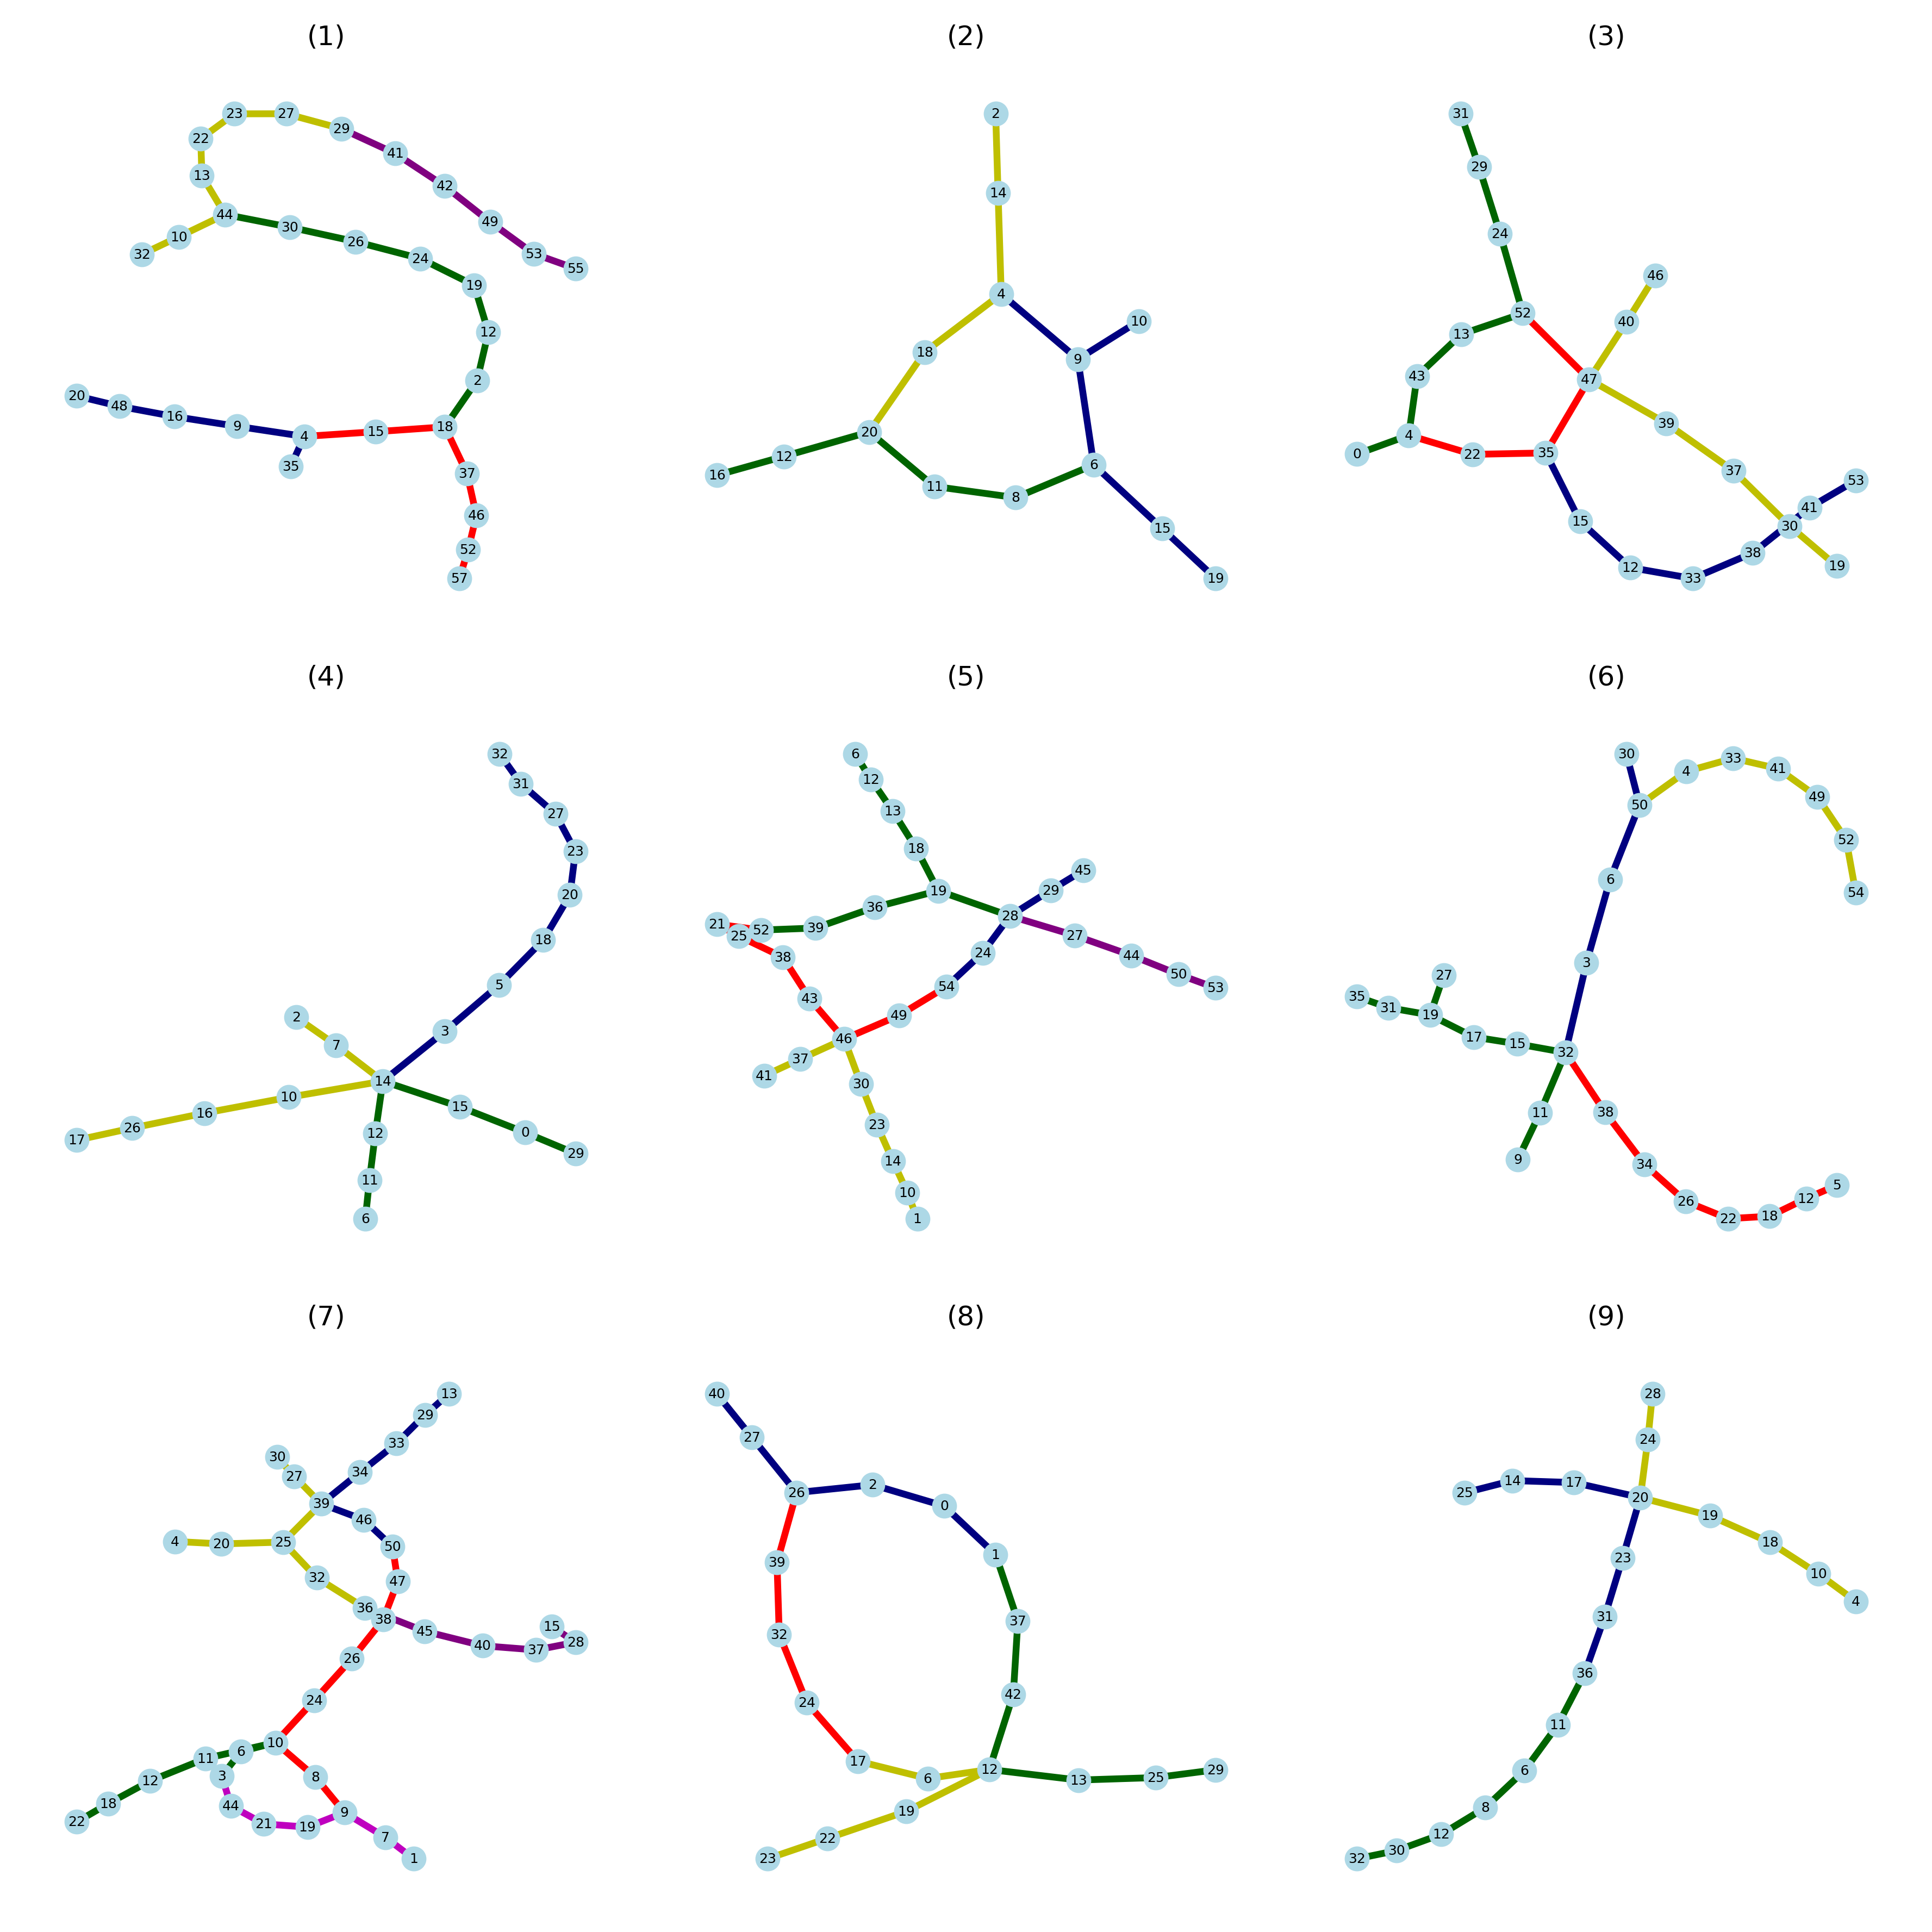

In [2]:
# Transit scenerio for testings
test_seeds = [828920903,
             115601515,
             989005593,  
             267626564, 
             913751312, 
             398943963, 
             436715962, 
             624311666, 
             433623492]

fig = plt.figure(figsize=(8,8), dpi=450)
for index, seed in enumerate(test_seeds,  1):
    env = TransitNetworkEnv({"is_training": True, "seed": seed, "zero_terminal_reward":True})
    obs, _ = env.reset()
    ax = plt.subplot(3,3, index)
    env.transit_system.topology.show(ax=ax, 
                                     node_size=40, 
                                     font_size=4, 
                                     black_edges=False, 
                                     show_legends=False, 
                                     title=f"({index})")
    fig.tight_layout()
plt.show()

## <b>Arrival and Departure patterns</b>

Out transit system contains multiple parts including `Bus stops`, `Vehicles`, `Routes`, `Passengers` etc. Each trabist system has different number of nodes and routes and has unique demographics and morphology. This means each of them has there own demand patterns a sample of that is shown below.

<Figure size 4500x4500 with 0 Axes>

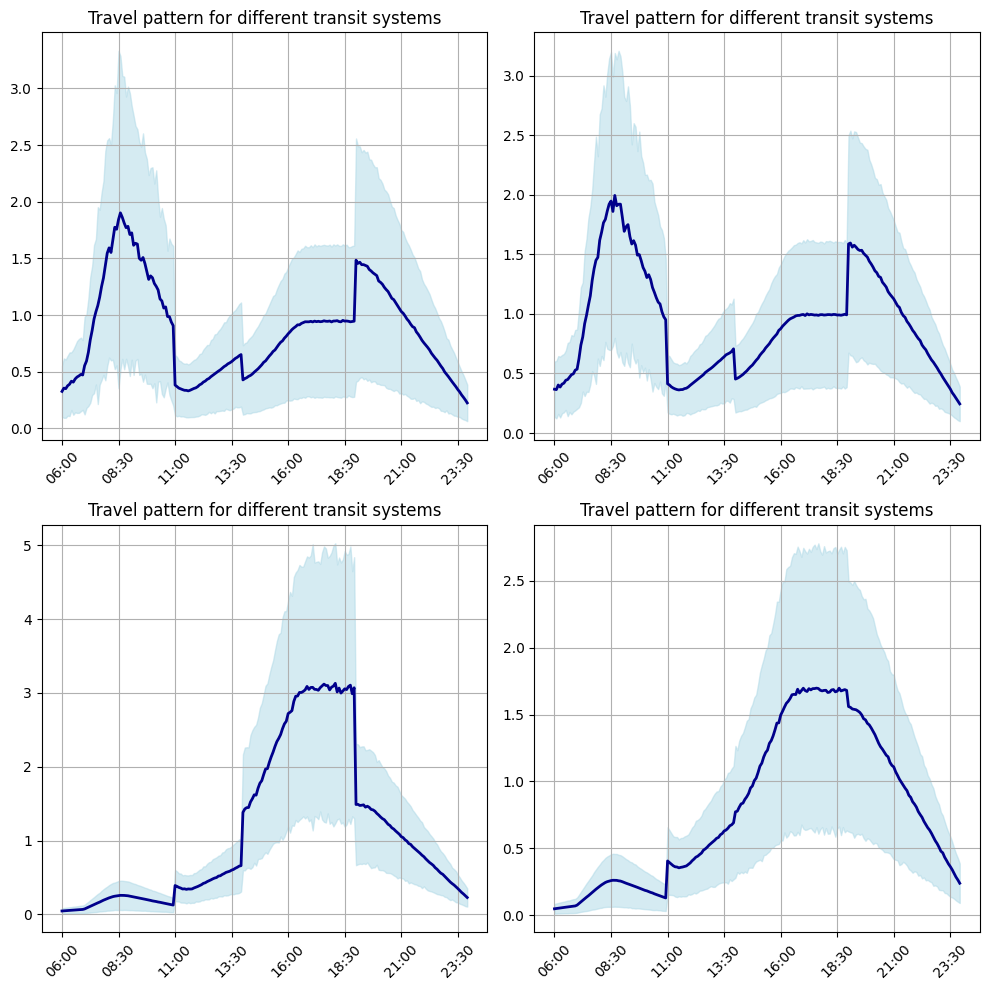

In [3]:
# Stats for different simulated transit system over the opperation horizon

arrs = []
plt.figure(figsize=(10,10), dpi=450)

for seed in test_seeds:
    
    env = TransitNetworkEnv({"is_training": True, "seed": seed, "zero_terminal_reward":True}) 
    _ = env.reset()
    dep, arr = env.transit_system.topology.show_report()
    arrs.append(arr)

data = {}
for arr in arrs:
    i = 0
    for a in arr[::2]:
        if i not in data:
            data[i] = {}
        for ii in range(len(a)):
            if ii not in data[i]:
                data[i][ii] = []
            data[i][ii].append(a[ii])
        i += 1

fig = plt.figure(figsize=(10, 10))
for xyz in range(4):
    plt.subplot(2,2,1+xyz)
    df = pd.DataFrame(data[xyz]).T    
    mean_data = df.mean(axis=1)
    
    std_data = df.std(axis=1)
    
    ci_multiplier = 2.0 
    lower_bound = mean_data - ci_multiplier * std_data
    upper_bound = mean_data + ci_multiplier * std_data
    
    x_index = df.index
    
    TIME_START_HOUR = 6
    TIME_STEP_MINUTES = 5
    
    def index_to_time_label(index_value, start_hour=TIME_START_HOUR, step_minutes=TIME_STEP_MINUTES):
        """Converts the integer index to a time string (e.g., 120 -> 16:00)."""
        
        total_minutes_elapsed = index_value * step_minutes
        
        hours_elapsed = total_minutes_elapsed // 60
        minutes_remainder = total_minutes_elapsed % 60
        
        current_hour = start_hour + hours_elapsed
        current_minute = minutes_remainder
    
        current_hour_mod_24 = current_hour % 24 
        
        return f"{current_hour_mod_24:02d}:{current_minute:02d}"
    
    tick_interval = 30
    max_index = df.index.max()
    tick_locations = np.arange(0, max_index + tick_interval, tick_interval)[:-1]
    
    tick_labels = [index_to_time_label(i) for i in tick_locations]
    
    
    plt.fill_between(
        x_index,
        lower_bound,
        upper_bound,
        color='lightblue', 
        alpha=0.5,
        label=f'{int(ci_multiplier)} $\sigma$ range' 
    )
    
    plt.plot(
        x_index,
        mean_data,
        color='darkblue', 
        linewidth=2,
        label='Mean'
    )
    plt.title("Travel pattern for different transit systems")

    plt.xticks(tick_locations, tick_labels, rotation=45) 
    plt.grid()

fig.tight_layout()

SMARTS uses a **GNN-Transformer** architecture that jointly captures:

1. **Spatial structure** via a Graph Neural Network (GNN) — encodes the topology of the transit network (stops and routes as graph nodes/edges)
2. **Temporal dependencies** via a Transformer encoder-decoder — captures sequential dispatch decisions across the operating horizon

Two model scales are evaluated:
- **SMARTS-SMALL:** GNN hidden dim = 128, 4 attention heads, 4 encoder / 8 decoder layers
- **SMARTS-LARGE:** GNN hidden dim = 1024, 16 attention heads, 8 encoder / 8 decoder layers

**Baselines compared:**
| Model | Description |
|-------|-------------|
| DNN-RL | Simple deep neural network RL agent, trained per transit system |
| Simulated Annealing (SA) | Heuristic optimizer, also trained per system |
| Fixed Headway (5/15/30 min) | Rule-based dispatch at fixed intervals |

All model weights and training configurations are saved and reloadable for full computational reproducibility.

In [4]:
# Initialize a dummy environment with seed=0 to extract observation and action space shapes
# needed for model construction. Training mode is enabled but this instance is only used
# for architecture inference, not actual training.
env = TransitNetworkEnv({"is_training": True, "seed": 0})

# Use GPU if available for faster training/inference, otherwise fall back to CPU
device = "cuda" if torch.cuda.is_available() else "cpu"


def get_small_smarts(device, load_weights=False, pth="results/small_smarts.pth"):
    """
    Build and return the lightweight SMARTS model (GNN-Transformer).

    This smaller variant is designed for faster training and inference while
    still capturing spatial and temporal transit scheduling patterns.

    Args:
        device (str): Target device — 'cuda' or 'cpu'.
        load_weights (bool): If True, load pre-trained weights from `pth`.
        pth (str): Path to the saved model state dict (.pth file).

    Returns:
        Model: SMARTS-SMALL model, moved to the specified device.
    """
    model = Model(
        env.observation_spaces["agent_0"],   # Observation space from a representative agent
        env.action_spaces["agent_0"],         # Action space (dispatch decisions per agent)
        gnn_hidden_dim=128,                   # Hidden dimension for GNN node embeddings
        gnn_num_heads=4,                      # Number of attention heads in the GNN layer
        embed_size=128,                       # Transformer embedding dimension
        transformer_num_heads=4,              # Number of attention heads in the Transformer
        num_encoder_layers=4,                 # Encoder depth (spatial context encoding)
        num_decoder_layers=8,                 # Decoder depth (sequential decision generation)
        dropout_rate=0.1,                     # Dropout for regularization during training
    )

    model = model.to(device)

    if load_weights:
        # Load weights to CPU first to avoid device mismatch, then let .to(device) handle placement
        model.load_state_dict(torch.load(pth, map_location=torch.device('cpu')))

    return model


def get_big_smarts(device, load_weights=False, pth="results/big_smarts.pth"):
    """
    Build and return the large-capacity SMARTS model (GNN-Transformer).

    This variant uses 8x larger embeddings and 4x more attention heads than
    SMARTS-SMALL, giving it greater capacity to model complex transit topologies
    at the cost of higher compute and memory requirements.

    Args:
        device (str): Target device — 'cuda' or 'cpu'.
        load_weights (bool): If True, load pre-trained weights from `pth`.
        pth (str): Path to the saved model state dict (.pth file).

    Returns:
        Model: SMARTS-LARGE model, moved to the specified device.
    """
    model = Model(
        env.observation_spaces["agent_0"],   # Observation space from a representative agent
        env.action_spaces["agent_0"],         # Action space (dispatch decisions per agent)
        gnn_hidden_dim=1024,                  # Larger GNN hidden dim for richer spatial encoding
        gnn_num_heads=16,                     # More attention heads for finer graph structure capture
        embed_size=1024,                      # Larger Transformer embedding for higher expressivity
        transformer_num_heads=16,             # More heads for richer temporal attention patterns
        num_encoder_layers=8,                 # Deeper encoder for complex spatial context
        num_decoder_layers=8,                 # Decoder depth matching encoder
        dropout_rate=0.1,                     # Same dropout rate as small model
    )

    model = model.to(device)

    if load_weights:
        # Load weights to CPU first to avoid device mismatch errors on CUDA systems
        model.load_state_dict(torch.load(pth, map_location=torch.device('cpu')))

    return model


def get_simple_model(env, device):
    """
    Build and return a simple DNN-based baseline agent (DNN-RL).

    Unlike SMARTS, this agent uses a plain deep neural network without graph
    or transformer components. It is trained independently per transit system
    and serves as a system-specific baseline to benchmark SMARTS generalization.

    Args:
        env: A TransitNetworkEnv instance used to infer observation/action spaces.
        device (str): Target device — 'cuda' or 'cpu'.

    Returns:
        SimpleDNNAgent: Baseline DNN agent, moved to the specified device.
    """
    model = SimpleDNNAgent(
        env,
        embed_size=1024,   # Large embedding to give the DNN baseline maximum capacity
    )

    model = model.to(device)

    return model

## <b>Results</b>

below is the reults of running the simulation with various schedulers. We ran each simulator with 18 hours of transit service. these parameters can be chnaged in `tansit_config.json` file.

It can be seen that despite never seeing these tranist systems SMARTS models are superior or comparable to DNN and SA whiche were specifically trainied for that transit system. This means that our models have generalized. In the charts below we have used the rewards accumulated by the scheduler for each tranist system.

- **Cumulative Reward:** Captures the overall quality of scheduling decisions over the operation horizon
- **Average Passenger Waiting Time (min):** Lower is better; directly measures service quality
- **Passengers Served:** Total successfully boarded passengers
- **Buses Deployed per Route:** Proxy for operational cost efficiency
- **Vehicle Occupancy Rate:** Passengers served per bus dispatch

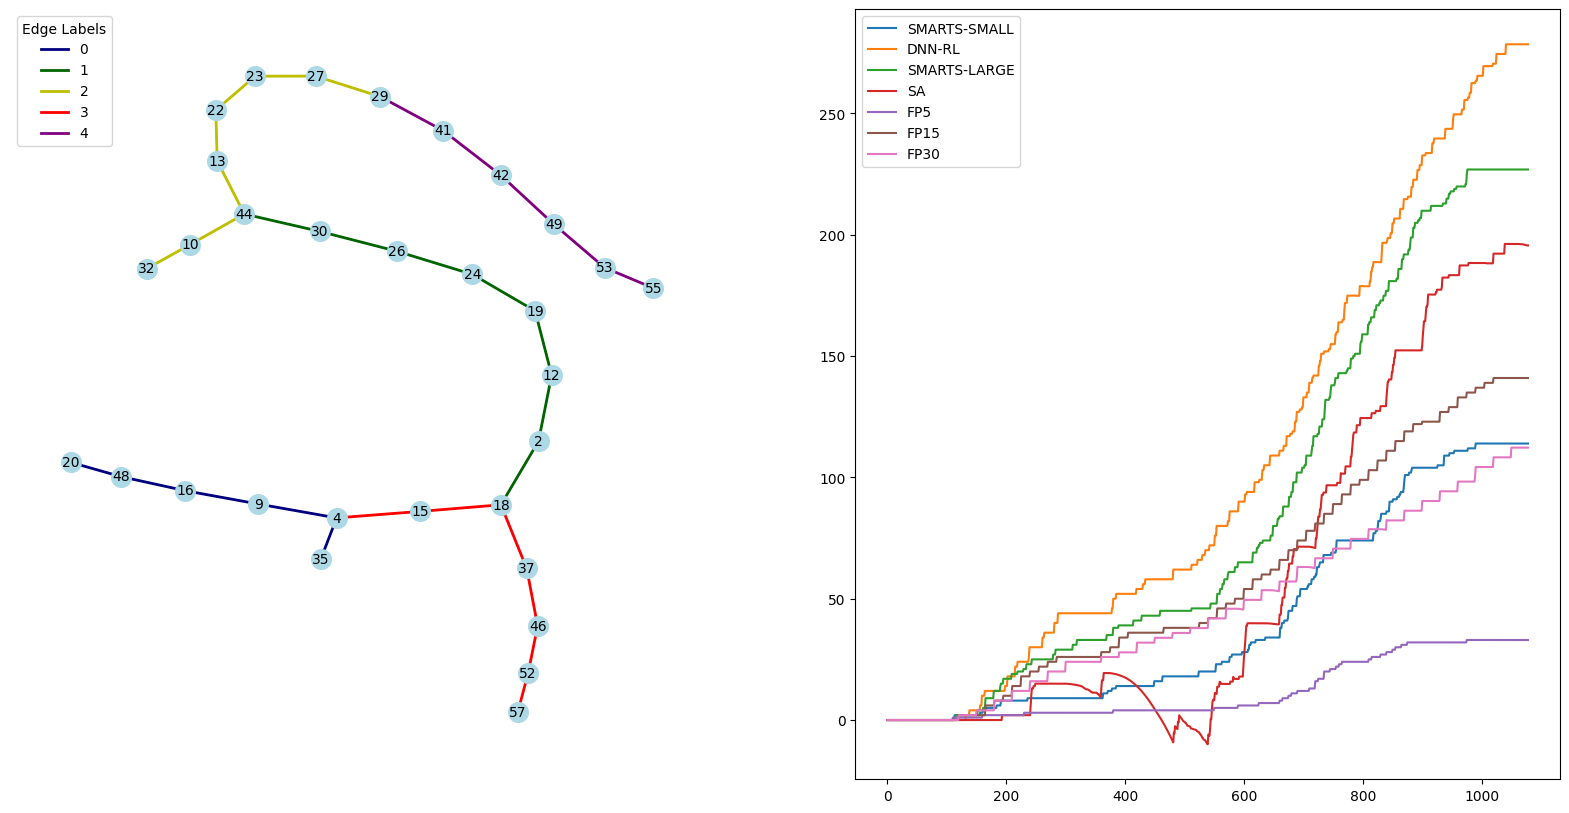

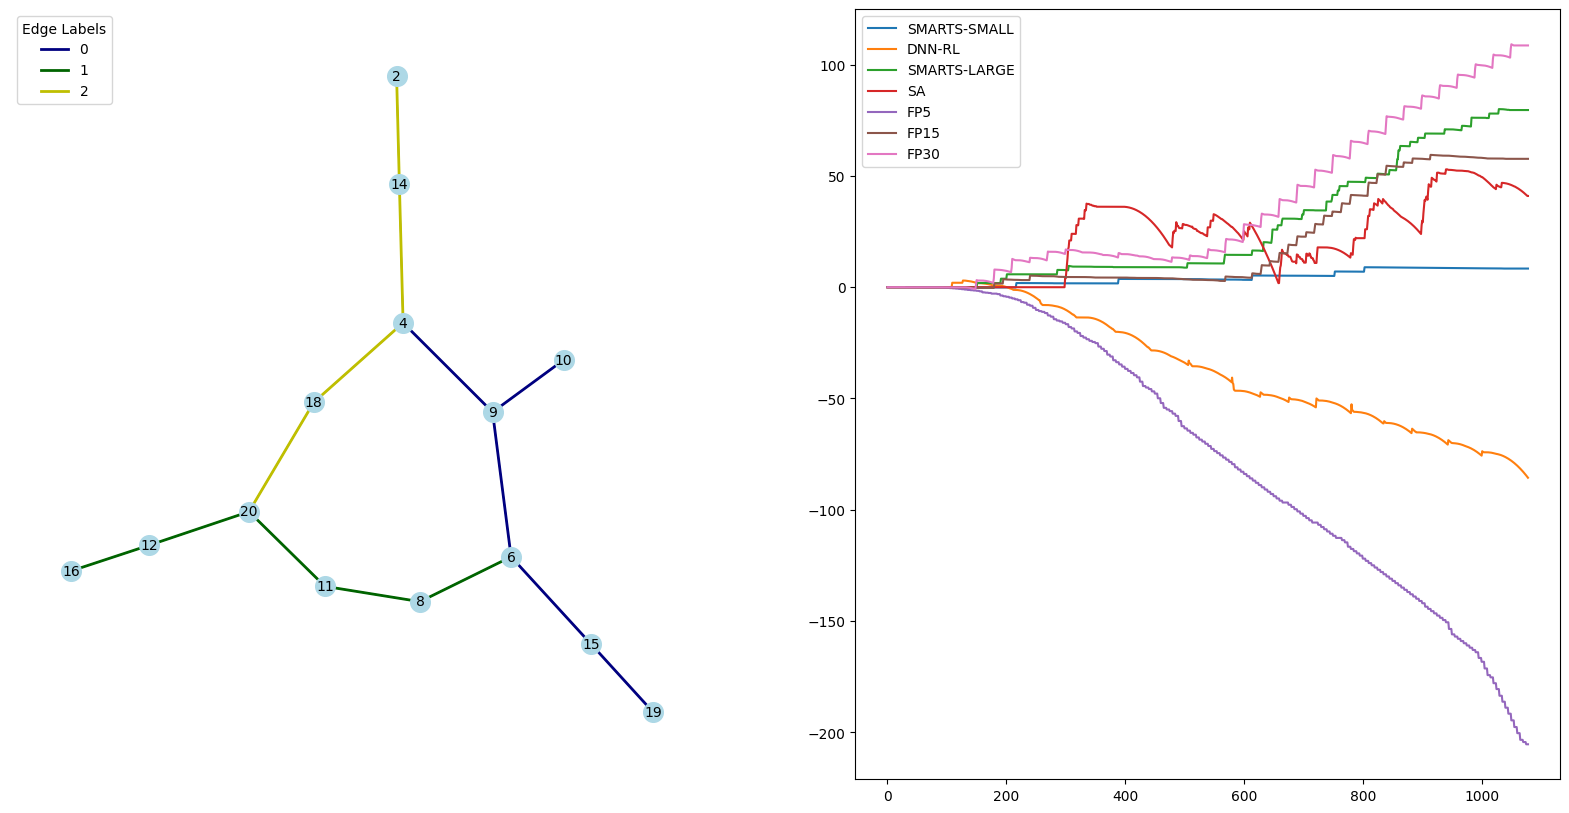

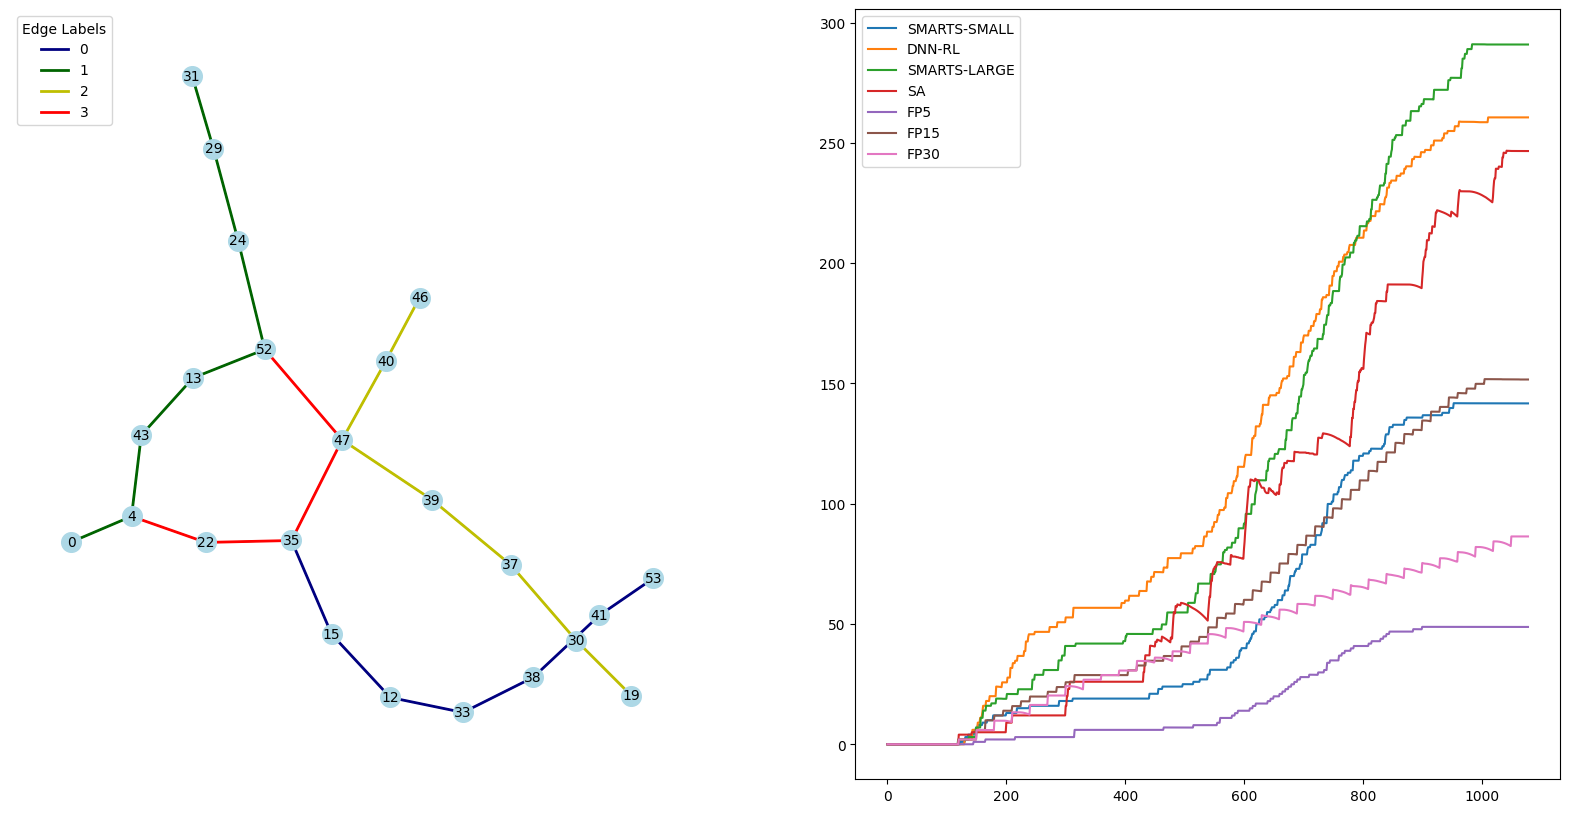

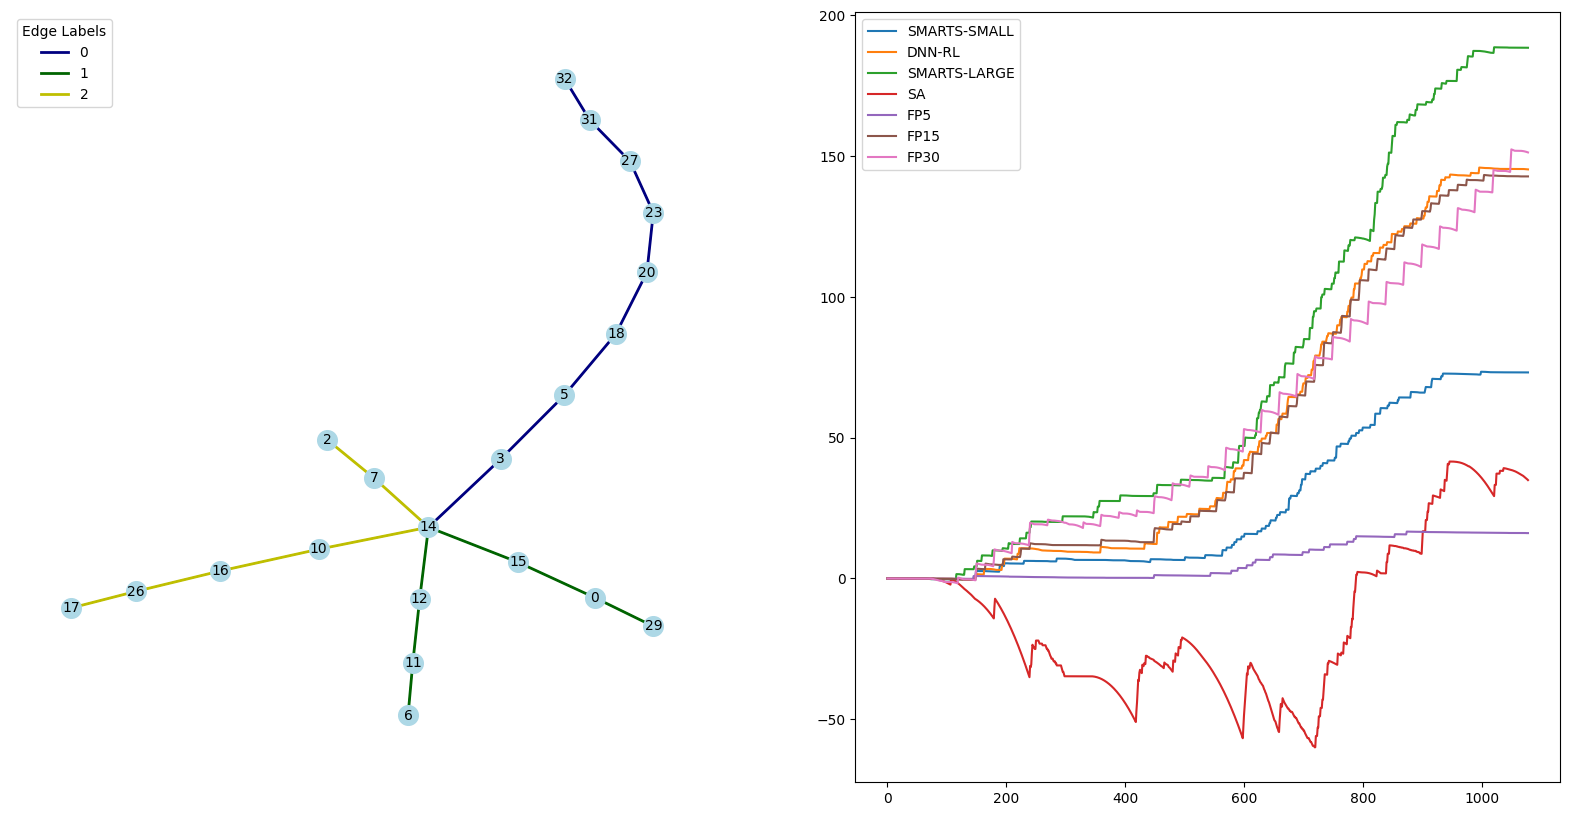

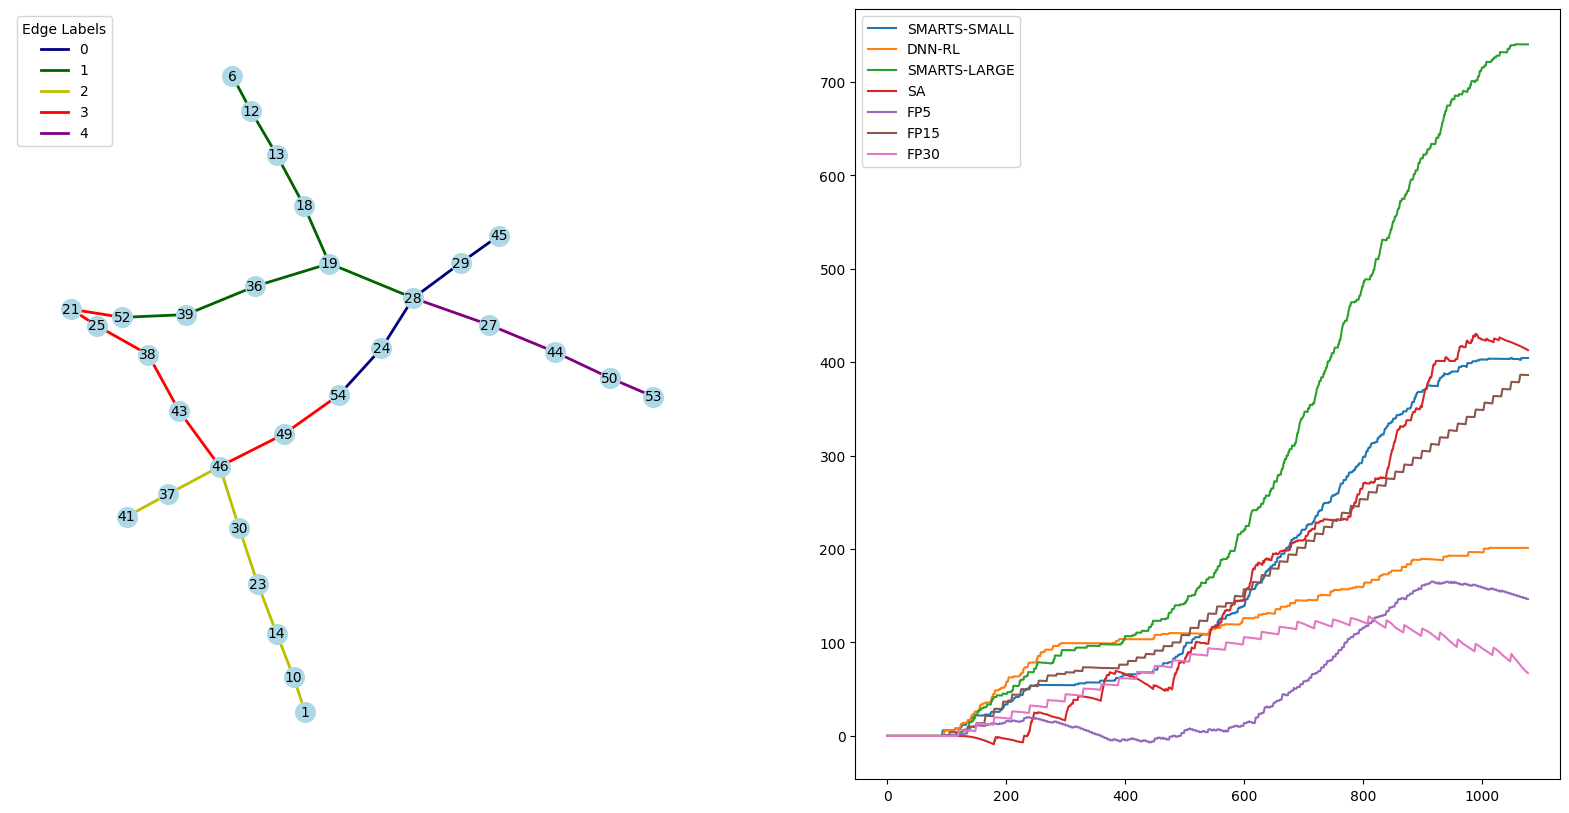

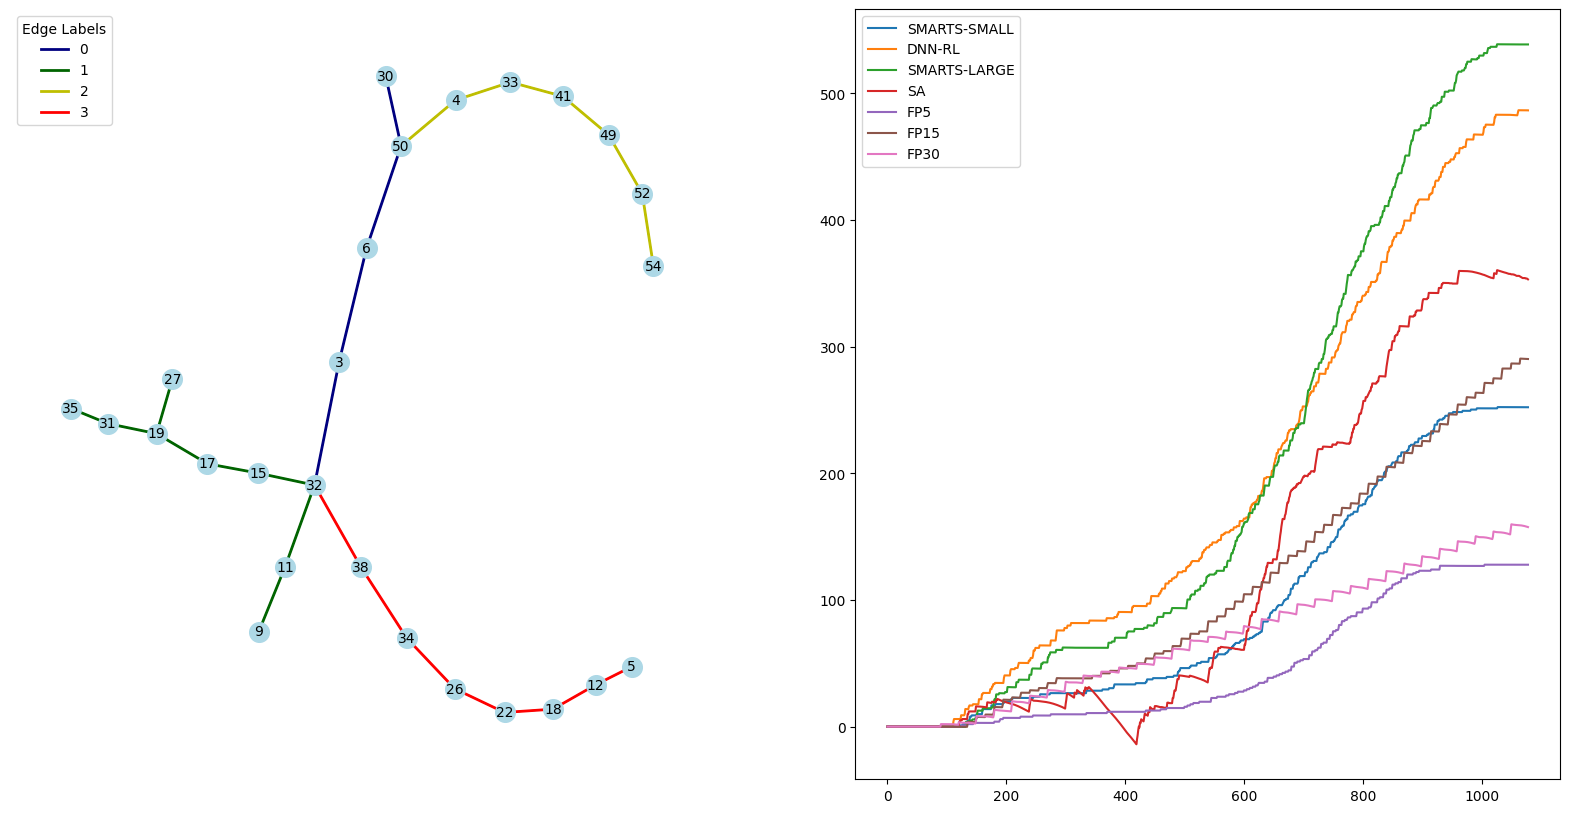

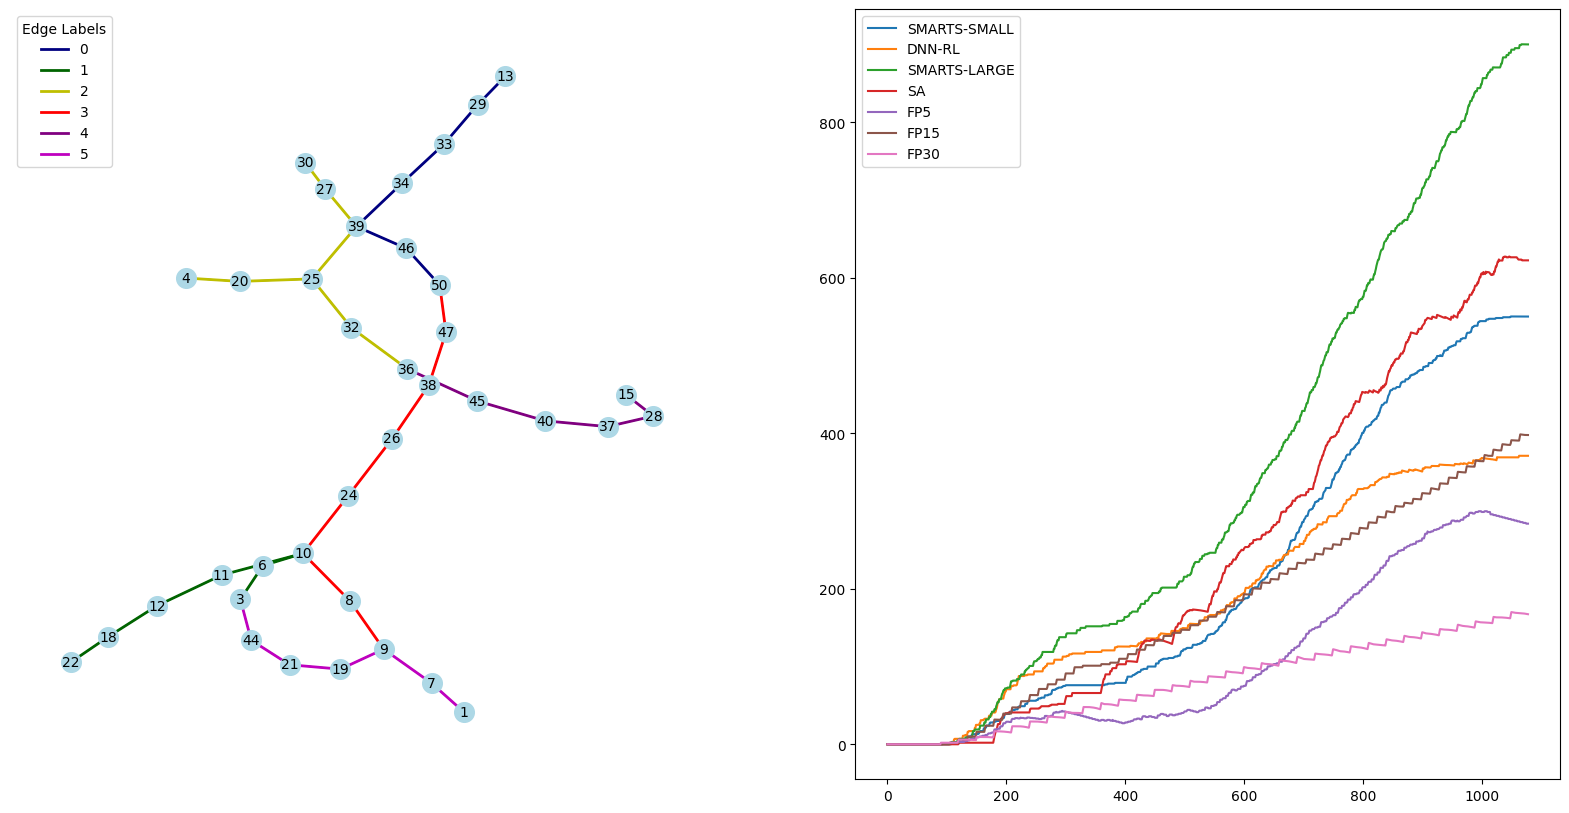

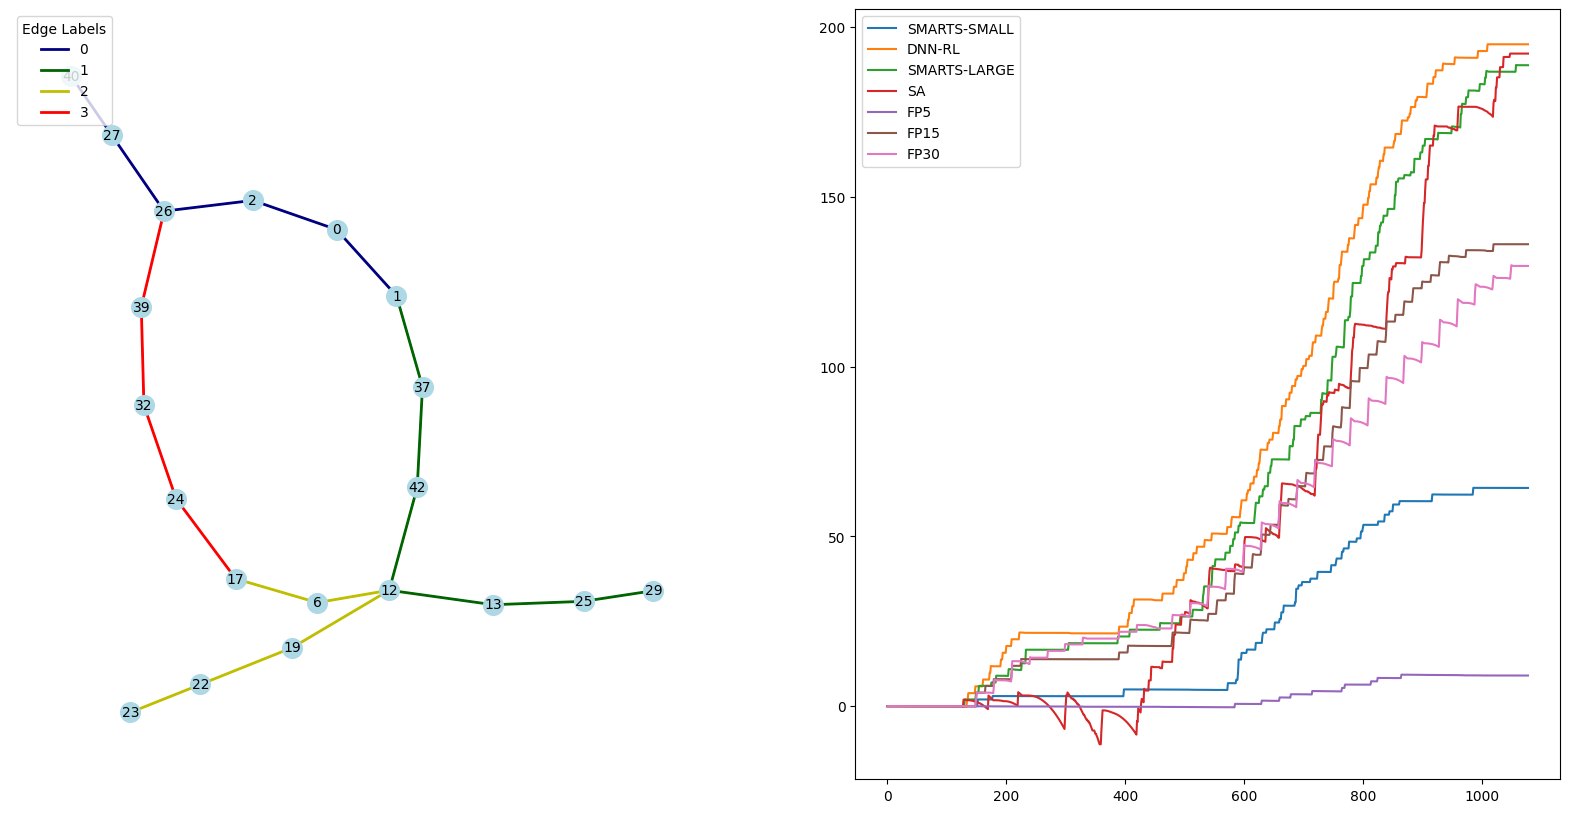

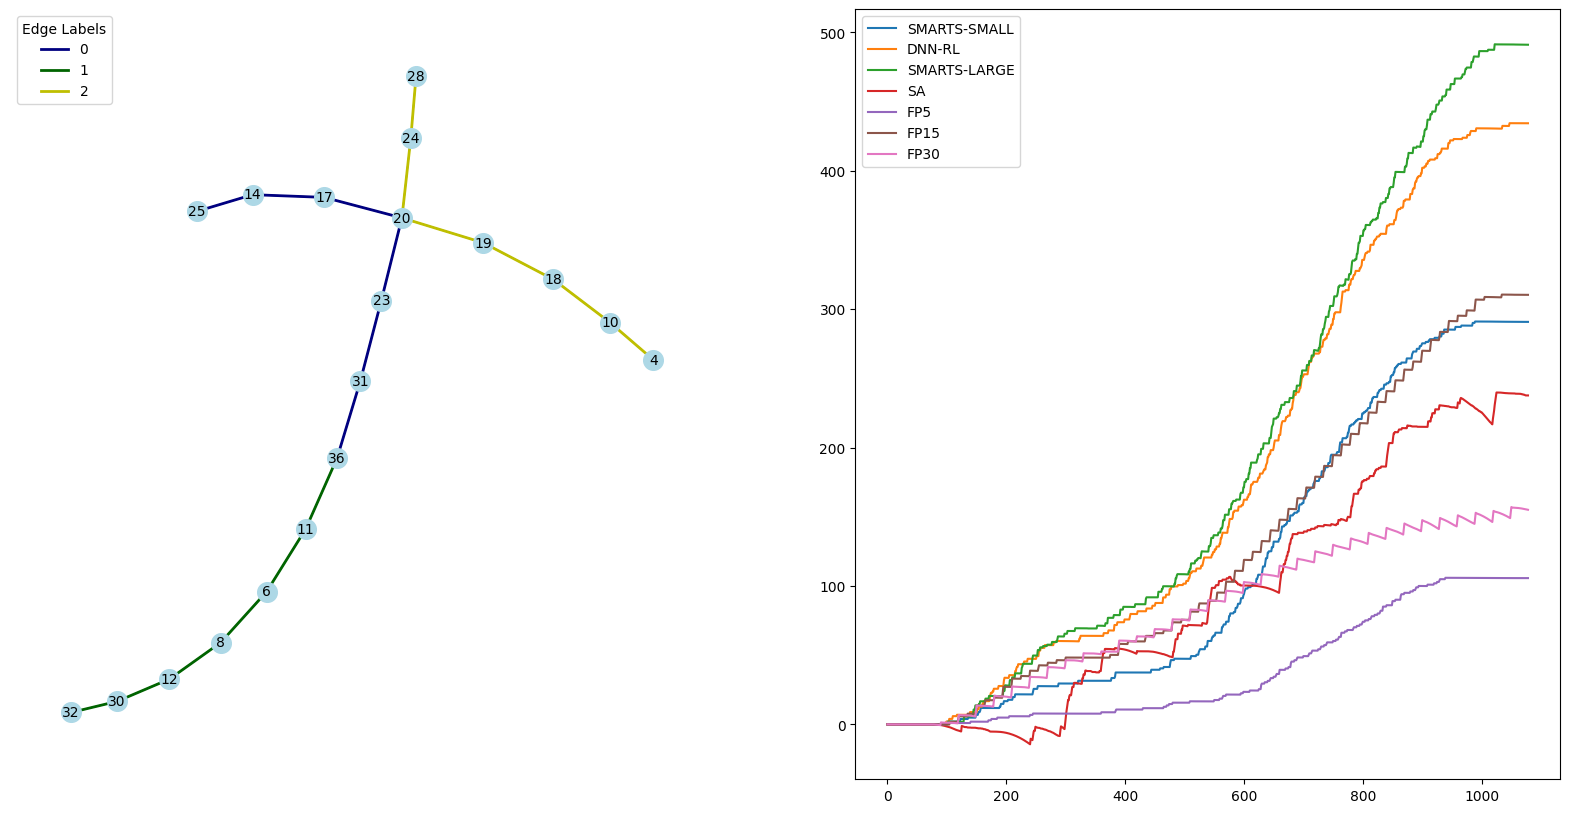

In [5]:
# Toggle to rerun all scheduler evaluations from scratch.
# Requires pre-trained model weights saved under results/.
# Set to False to load previously cached results instead (much faster).
REDO = False

if REDO:
    # -------------------------------------------------------------------------
    # LIVE EVALUATION MODE: Run all schedulers on each test transit system
    # and collect rewards, actions, and diagnostic reports from scratch.
    # -------------------------------------------------------------------------

    total_deployed_buses_by_policy = 0
    total_deployed_buses_by_random = 0
    reports = []     # Stores per-run transit system diagnostic reports
    all_rewards = [] # Stores reward sequences for every policy × seed combination
    window = 1       # Rolling window size for reward aggregation (1 = no smoothing)

    for seed in test_seeds:

        # Set up a side-by-side figure: left = transit topology, right = cumulative rewards
        fig = plt.figure(figsize=(20, 10), dpi=450)
        (ax_1, ax_2) = fig.subplots(1, 2)
        to_print = ""
        all_log = []

        # -----------------------------------------------------------------
        # SCHEDULER 1: SMARTS-SMALL (GNN-Transformer, lightweight variant)
        # -----------------------------------------------------------------

        # Instantiate the environment for this test seed and visualize its topology
        env = TransitNetworkEnv({"is_training": True, "seed": seed, "zero_terminal_reward": True})
        obs, _ = env.reset()
        env.transit_system.topology.show(ax=ax_1)

        # Load SMARTS-SMALL with pre-trained weights and set to evaluation mode
        model = get_small_smarts(device, load_weights=True)
        model.to(device)
        model.eval()

        # Re-instantiate the environment to get a clean episode for rollout
        env = TransitNetworkEnv({"is_training": True, "seed": seed, "zero_terminal_reward": True})
        (
            obs_buf,       # Observations at each step for each agent
            action_buf,    # Actions taken at each step for each agent
            reward_buf,    # Rewards received at each step for each agent
            terminated_buf,
            truncated_buf,
            info_buf,
            logp_buf,      # Log-probabilities of sampled actions (used during training)
            value_buf,     # Value estimates from the critic (used during training)
        ) = collect_rollout(env, model, rollout_len=100_000, device=device, hard_reset=True, testing=True)
        reports.append(env.transit_system.report)

        # Aggregate actions and rewards across agents into timestep-indexed dicts
        actions = {}
        rewards = {}
        for agent_id in env.possible_agents:
            for i in range(len(reward_buf[agent_id])):
                if i not in actions:
                    actions[i] = []
                actions[i].append(action_buf[agent_id][i])

                if i not in rewards:
                    rewards[i] = []
                rewards[i].append(reward_buf[agent_id][i])

        # Flatten all agent rewards into a single series and compute a rolling max
        # to get the best reward achieved within each window (step = window avoids overlap)
        policy_rewards = (
            pd.Series(sum([i for i in rewards.values()], []))
            .rolling(window=len(env.possible_agents) * window, step=len(env.possible_agents) * window)
            .max()
            .dropna()
            .to_list()
        )
        all_rewards.append(policy_rewards)

        # Count total bus dispatches averaged across agents
        total_deployed_buses_by_policy = sum([sum(i) for i in actions.values()]) / float(len(env.possible_agents))
        to_print += f"deployed_buses_gnn={total_deployed_buses_by_policy.item():.3f}, mean_rewards={np.mean(policy_rewards):.4f}"

        # -----------------------------------------------------------------
        # SCHEDULER 2: DNN-RL (system-specific deep network baseline)
        # Each test seed has its own dedicated model trained for that topology.
        # -----------------------------------------------------------------

        env = TransitNetworkEnv({"is_training": True, "seed": seed, "zero_terminal_reward": True})
        model = get_simple_model(env, device).eval()

        # Load the DNN-RL weights trained specifically for this transit topology
        model.load_state_dict(torch.load(f"results/RLRT_SCH/{seed}.pth", map_location=torch.device('cpu')))
        model.to(device)
        model.eval()

        env = TransitNetworkEnv({"is_training": True, "seed": seed, "zero_terminal_reward": True})
        (
            obs_buf,
            action_buf,
            reward_buf,
            terminated_buf,
            truncated_buf,
            info_buf,
            logp_buf,
            value_buf,
        ) = collect_rollout(env, model, rollout_len=100_000, device=device, hard_reset=True, testing=True)
        reports.append(env.transit_system.report)

        actions = {}
        rewards = {}
        for agent_id in env.possible_agents:
            for i in range(len(reward_buf[agent_id])):
                if i not in actions:
                    actions[i] = []
                actions[i].append(action_buf[agent_id][i])

                if i not in rewards:
                    rewards[i] = []
                rewards[i].append(reward_buf[agent_id][i])

        dnnrl_rewards = (
            pd.Series(sum([i for i in rewards.values()], []))
            .rolling(window=len(env.possible_agents) * window, step=len(env.possible_agents) * window)
            .max()
            .dropna()
            .to_list()
        )
        all_rewards.append(dnnrl_rewards)
        total_deployed_buses_by_dnnrl = sum([sum(i) for i in actions.values()]) / float(len(env.possible_agents))
        to_print += f"\ndeployed_buses_dnnrl={total_deployed_buses_by_dnnrl.item():.3f}, mean_rewards={np.mean(dnnrl_rewards):.4f}"

        # -----------------------------------------------------------------
        # SCHEDULER 3: SMARTS-LARGE (GNN-Transformer, high-capacity variant)
        # -----------------------------------------------------------------

        env = TransitNetworkEnv({"is_training": True, "seed": seed, "zero_terminal_reward": True})
        obs, _ = env.reset()

        # Load SMARTS-LARGE with pre-trained weights and set to evaluation mode
        model = get_big_smarts(device, load_weights=True).eval()
        model.to(device)
        model.eval()

        env = TransitNetworkEnv({"is_training": True, "seed": seed, "zero_terminal_reward": True})
        (
            obs_buf,
            action_buf,
            reward_buf,
            terminated_buf,
            truncated_buf,
            info_buf,
            logp_buf,
            value_buf,
        ) = collect_rollout(env, model, rollout_len=100_000, device=device, hard_reset=True, testing=True)
        reports.append(env.transit_system.report)

        actions = {}
        rewards = {}
        for agent_id in env.possible_agents:
            for i in range(len(reward_buf[agent_id])):
                if i not in actions:
                    actions[i] = []
                actions[i].append(action_buf[agent_id][i])

                if i not in rewards:
                    rewards[i] = []
                rewards[i].append(reward_buf[agent_id][i])

        bigGNN_rewards = (
            pd.Series(sum([i for i in rewards.values()], []))
            .rolling(window=len(env.possible_agents) * window, step=len(env.possible_agents) * window)
            .max()
            .dropna()
            .to_list()
        )
        all_rewards.append(bigGNN_rewards)
        total_deployed_buses_by_bigGNN = sum([sum(i) for i in actions.values()]) / float(len(env.possible_agents))
        to_print += f"\ndeployed_buses_bigGNN={total_deployed_buses_by_bigGNN.item():.3f}, mean_rewards={np.mean(bigGNN_rewards):.4f}"

        # -----------------------------------------------------------------
        # SCHEDULER 4: Simulated Annealing (SA) — system-specific heuristic
        # SA timetables are pre-computed and stored as pickled policy dicts.
        # A retry loop handles intermittent I/O failures on network storage.
        # -----------------------------------------------------------------

        env = TransitNetworkEnv({"is_training": True, "seed": seed, "zero_terminal_reward": True})

        loaded = False
        while not loaded:
            try:
                with open(f"results/SA_TT/{seed}.pkl", "rb") as file:
                    sa_tt = pkl.load(file)
                loaded = True
            except Exception as e:
                # Retry on failure — useful when reading from slow/network-mounted storage
                print(f"Error loading SA_TT for seed {seed}: {e}")
                print("Retrying...")
                time.sleep(3)

        # Wrap the SA timetable in a dict so collect_rollout can call model["policy"]
        model = {"policy": sa_tt}

        (
            obs_buf,
            action_buf,
            reward_buf,
            terminated_buf,
            truncated_buf,
            info_buf,
            logp_buf,
            value_buf,
        ) = collect_rollout(env, model, rollout_len=100_000, device=device, hard_reset=True, testing=True)
        reports.append(env.transit_system.report)

        actions = {}
        rewards = {}
        for agent_id in env.possible_agents:
            for i in range(len(reward_buf[agent_id])):
                if i not in actions:
                    actions[i] = []
                actions[i].append(action_buf[agent_id][i])

                if i not in rewards:
                    rewards[i] = []
                rewards[i].append(reward_buf[agent_id][i])

        sa_rewards = (
            pd.Series(sum([i for i in rewards.values()], []))
            .rolling(window=len(env.possible_agents) * window, step=len(env.possible_agents) * window)
            .max()
            .dropna()
            .to_list()
        )
        all_rewards.append(sa_rewards)
        total_deployed_buses_by_sa = sum([sum(i) for i in actions.values()]) / float(len(env.possible_agents))
        to_print += f"\ndeployed_buses_sa={total_deployed_buses_by_sa.item():.3f}, mean_rewards={np.mean(sa_rewards):.4f}"

        # -----------------------------------------------------------------
        # SCHEDULER 5: Fixed Headway (rule-based baseline)
        # Dispatches buses at fixed intervals of 5, 15, and 30 minutes.
        # Serves as the simplest possible reference policy.
        # -----------------------------------------------------------------

        for minute in [5, 15, 30]:
            env = TransitNetworkEnv({"is_training": True, "seed": seed, "zero_terminal_reward": True})
            (
                obs_buf,
                action_buf,
                reward_buf,
                terminated_buf,
                truncated_buf,
                info_buf,
                logp_buf,
                value_buf,
            ) = collect_rollout(
                env,
                fixed_policy(minute * 60),  # Convert dispatch interval from minutes to seconds
                rollout_len=100_000,
                device=device,
                hard_reset=True,
                testing=True,
            )
            reports.append(env.transit_system.report)

            actions = {}
            rewards = {}
            for agent_id in env.possible_agents:
                for i in range(len(reward_buf[agent_id])):
                    if i not in actions:
                        actions[i] = []
                    actions[i].append(action_buf[agent_id][i])

                    if i not in rewards:
                        rewards[i] = []
                    rewards[i].append(reward_buf[agent_id][i])

            fp_rewards = (
                pd.Series(sum([i for i in rewards.values()], []))
                .rolling(window=len(env.possible_agents) * window, step=len(env.possible_agents) * window)
                .max()
                .dropna()
                .to_list()
            )
            all_rewards.append(fp_rewards)
            total_deployed_buses_by_fp = sum([sum(i) for i in actions.values()]) / float(len(env.possible_agents))

            # Plot cumulative reward curve for this fixed headway interval
            ax_2.plot(np.cumsum(fp_rewards), label=f"FP{minute}")
            to_print += f"\ntotal_deployed_buses_by_fp{minute}={total_deployed_buses_by_fp:.3f}, mean_reward={np.mean(fp_rewards):.4f}"

        # Plot cumulative reward curves for all learned/heuristic policies together
        ax_2.plot(np.cumsum(dnnrl_rewards), label="DNN-RL")
        ax_2.plot(np.cumsum(policy_rewards), label="GNN")
        ax_2.plot(np.cumsum(bigGNN_rewards), label="bigGNN")
        ax_2.plot(np.cumsum(sa_rewards), label="SA")

        ax_2.legend()
        plt.show()

        print(to_print)
        print()

        # Cache results after each seed so progress is not lost if the run is interrupted
        with open("results/cached_runs.pkl", "wb") as file:
            pkl.dump((all_rewards, reports), file)

else:
    # -------------------------------------------------------------------------
    # CACHED RESULTS MODE: Skip re-running simulations and load saved outputs.
    # Much faster — use this for visualization and analysis after an initial run.
    # -------------------------------------------------------------------------

    with open("results/cached_runs.pkl", "rb") as file:
        (all_rewards, reports) = pkl.load(file)

    # Sequential index into all_rewards, which is ordered as:
    # [SMARTS-SMALL, DNN-RL, SMARTS-LARGE, SA, FP5, FP15, FP30] × len(test_seeds)
    i = 0

    for seed in test_seeds:

        fig = plt.figure(figsize=(20, 10))
        (ax_1, ax_2) = fig.subplots(1, 2)
        to_print = ""
        all_log = []

        # Reconstruct the transit topology for the left panel
        env = TransitNetworkEnv({"is_training": True, "seed": seed, "zero_terminal_reward": True})
        obs, _ = env.reset()
        env.transit_system.topology.show(ax=ax_1)

        # Unpack reward sequences in the same order they were stored during REDO
        small_smarts_rewards = all_rewards[i]; i += 1
        dnn_rl_rewards       = all_rewards[i]; i += 1
        big_smarts_rewards   = all_rewards[i]; i += 1
        sa_rewards           = all_rewards[i]; i += 1

        # Plot cumulative reward curves for all policies on the right panel
        ax_2.plot(np.cumsum(small_smarts_rewards), label="SMARTS-SMALL")
        ax_2.plot(np.cumsum(dnn_rl_rewards),       label="DNN-RL")
        ax_2.plot(np.cumsum(big_smarts_rewards),   label="SMARTS-LARGE")
        ax_2.plot(np.cumsum(sa_rewards),           label="SA")

        # Unpack and plot the three fixed headway baselines
        for minute in [5, 15, 30]:
            fp_rewards = all_rewards[i]; i += 1
            ax_2.plot(np.cumsum(fp_rewards), label=f"FP{minute}")

        ax_2.legend()
        plt.show()

        print(to_print)
        print()

## <b>Results</b>

Here we have shown the aggeragted rewarads for specific hour of opperation by each transit-scheduler across transit-systems. We can see that the SMARTS-BIG and SMALL are showing superior perfromance on unseen topologies. DNN and SA were trained specifically for the tranist-system there were used.

In [9]:
names = ["SMARTS-SMALL", "DNN-RL", "SMARTS-LARGE", "SA", "5 min", "15 min", "30 min"]

window = 60
n = len(names)
N = 9
res = pd.concat([pd.concat([pd.DataFrame(r).T.rolling(window=window, step=window).mean().dropna().iloc[:, i] for i in range(N)]).to_frame().rename(columns={0: name})
               for r, name in zip([[all_rewards[i] for i in range(j,n*N,n)] for j in range(n)], names) ], axis=1).reset_index()
res = pd.melt(res, id_vars=["index"], value_vars=names).rename(columns={"value": "reward", "variable": "Policy", "index": "time"})

plt.figure(figsize=(32,12), dpi=500)
fs = 16
mask = (res.Policy != "Uniform PD")
sns.boxplot(data=res.loc[mask], x="time", y="reward", hue="Policy")
time_labels = np.array(sorted(res.time.unique().tolist()))
plt.xticks(ticks=range(0,len(time_labels)), labels=[f"{int(i/60)+5}:{int(i/60 - int(i/60)):02d}" for i in time_labels], rotation=90)

plt.xlabel("time [hr]",  fontsize=fs)
plt.ylabel("Hourly rewards",  fontsize=fs)
plt.legend(fontsize=fs)

## <b>Results</b>

It would be biased to just compare the perfromance based on our own definced reward function/objective function. So, to find out if we have achived good perfromance we also used other metrices like `waiting time`, `number of deployed vehicles` etc. These metrices tells a lot about the cost and quality of the service. 

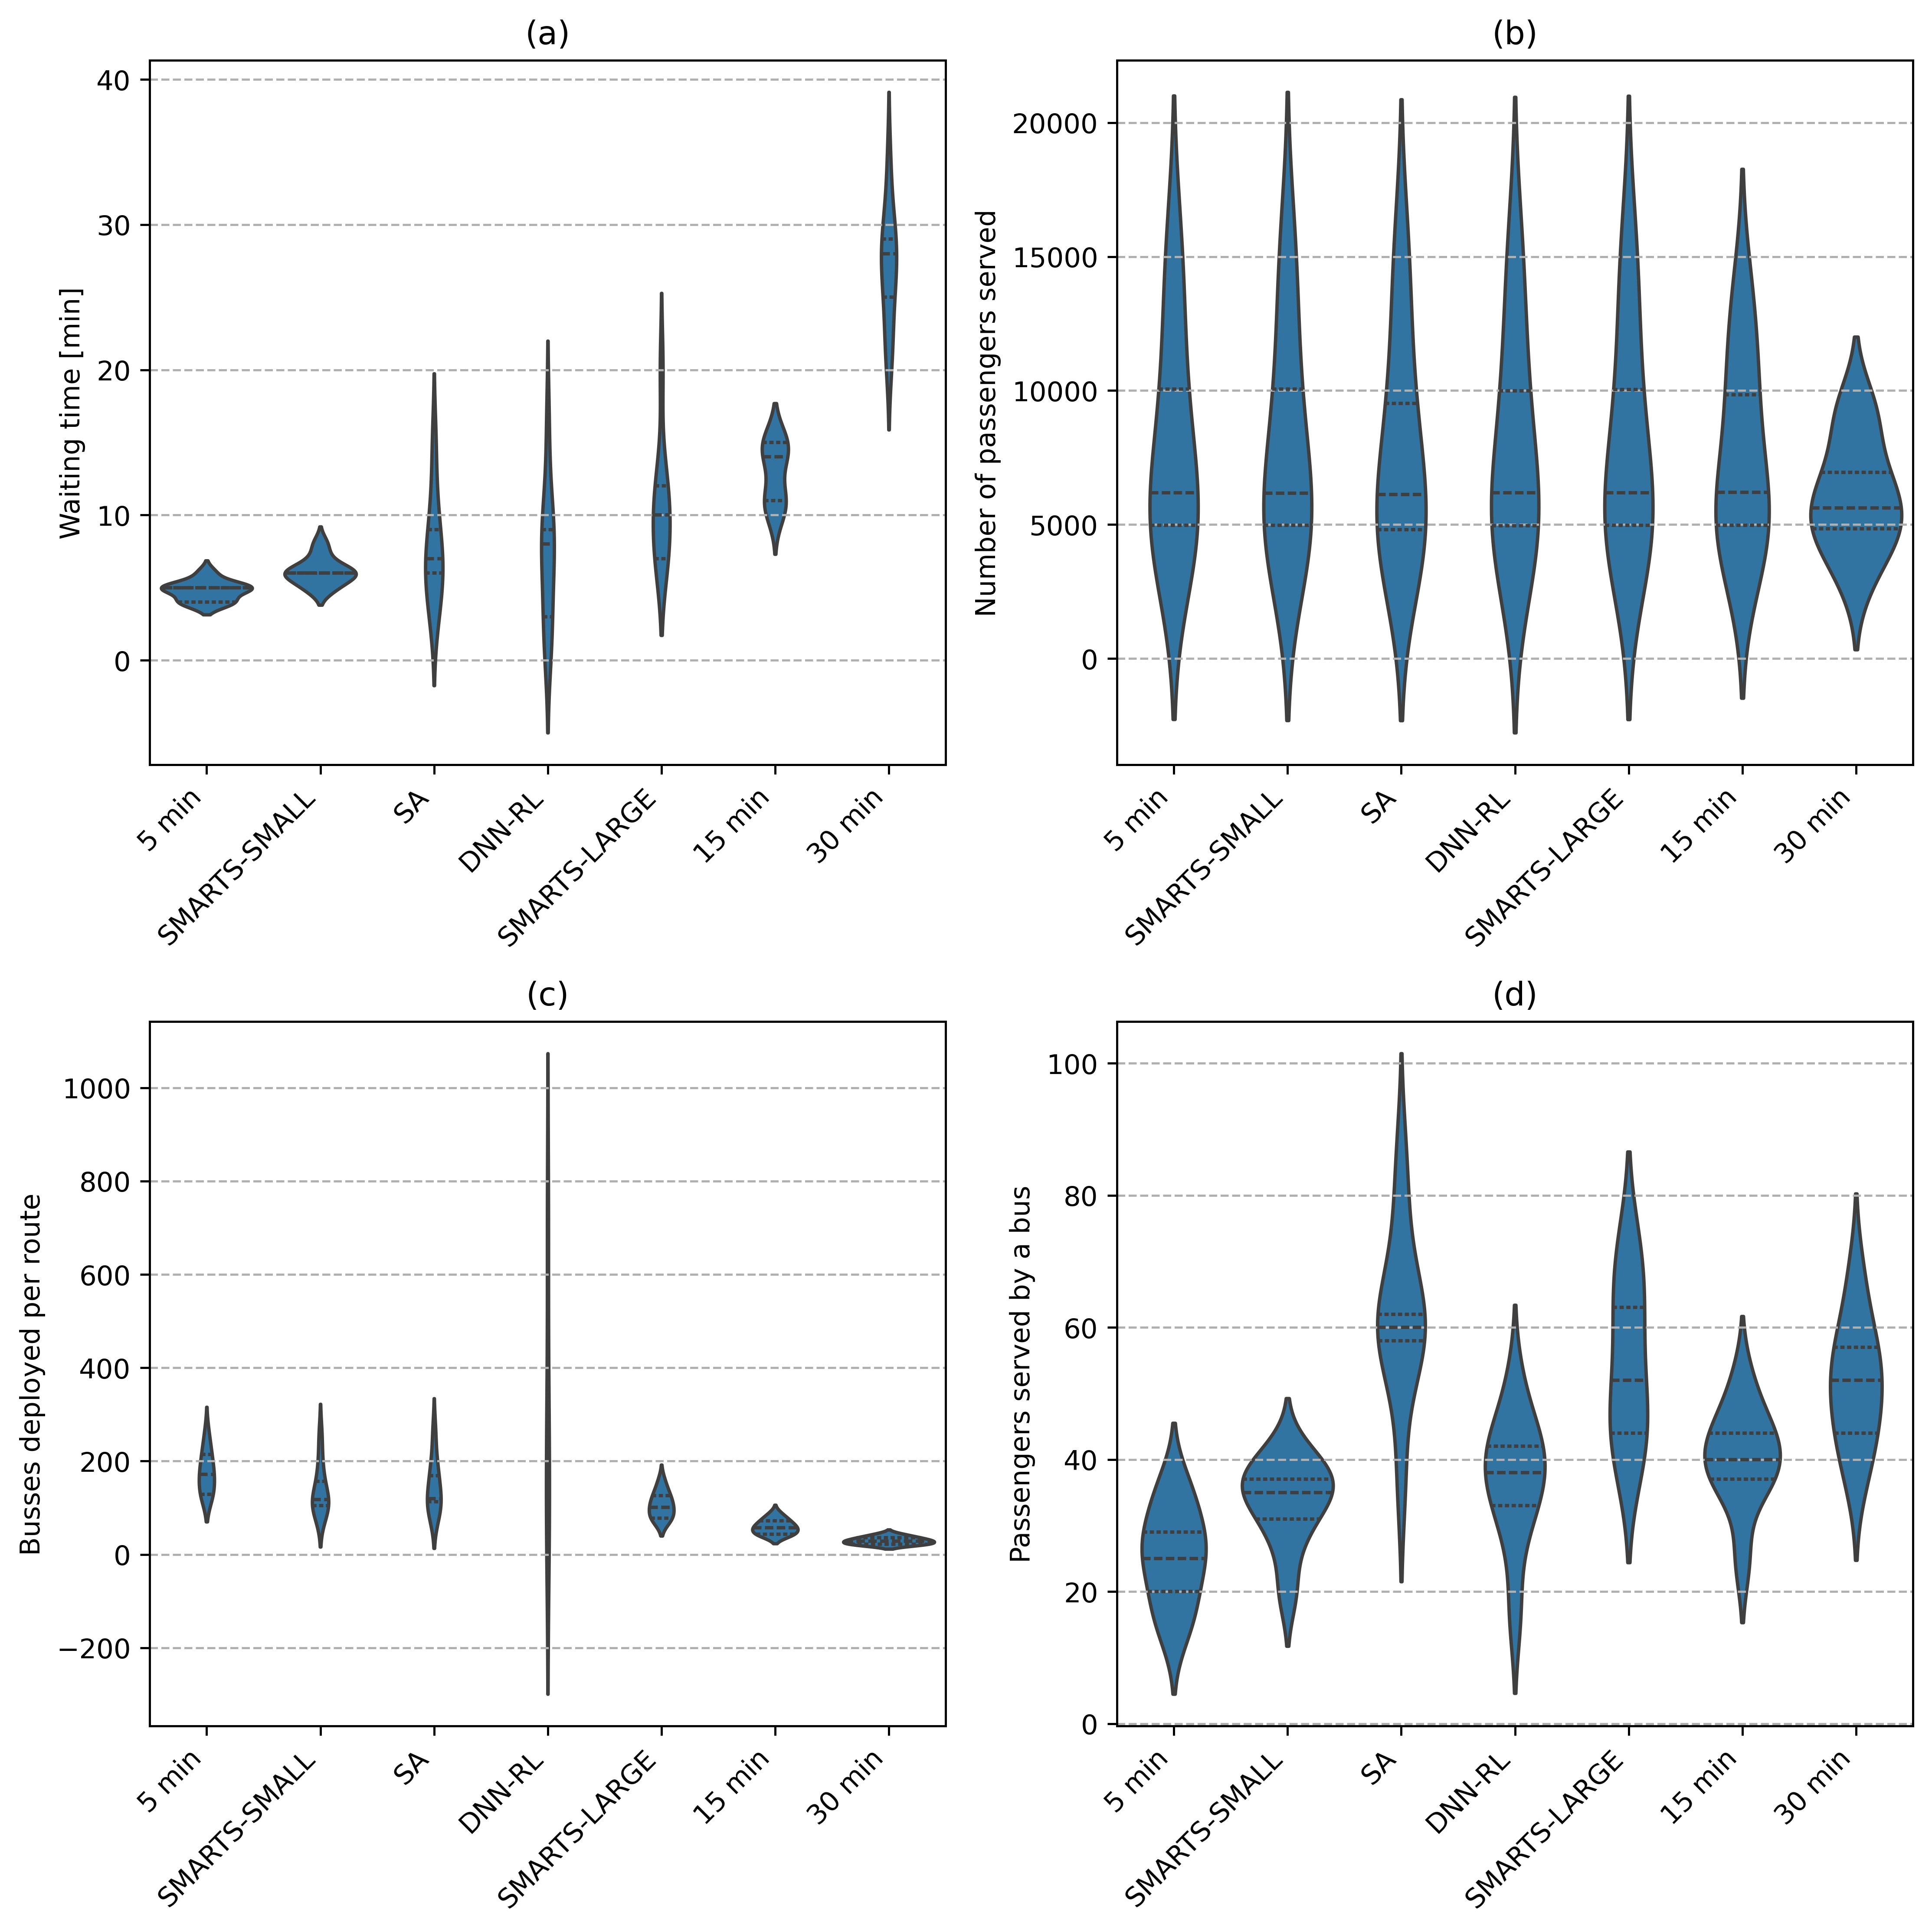

In [25]:
n = len(names)
N = 9
ii = 0
jj = n
fff = []
for _ in range(N):
    num_routes = len([k for k in reports[0][0] if "served_passengers" in k]) - 1
    ff = (pd.concat([pd.DataFrame(reports[i]).T[['total_deployed_buses', 
                                           'total_done_buses', 
                                           'total_avg_waiting_time', 
                                           'total_avg_average_stranded_count',
                                           'served_passengers',
                                           'vehicle_occupancy_rate']]
                    .assign(vehicle_occupancy_rate=lambda x: x.vehicle_occupancy_rate.map(lambda x: None if len(x)==0 else np.mean(x)))
                    .agg({'total_done_buses':"sum", 
                          'total_avg_waiting_time':"median", 
                          'total_avg_average_stranded_count':"median", 
                          'served_passengers':"sum",
                          'vehicle_occupancy_rate': "max"})
                    .dropna() for i in range(ii,jj)], axis=1)
                    .rename(columns={i:n for i,n in enumerate(names)}).T
                    .assign(done_buses_per_route= lambda x: x.total_done_buses/num_routes))
    
    fff.append(ff)
    ii = jj
    jj += n
fff = pd.concat(fff).reset_index().rename(columns={"index": "policy"})

dpi = 450
figsize = (10, 10)

try:
    order = fff.groupby('policy')['total_avg_waiting_time'].median().sort_values().index
except KeyError:
    order = None 

fig = plt.figure(figsize=figsize, dpi=dpi)

plt.subplot(2, 2, 1)
sns.violinplot(data=fff[["policy", "total_avg_waiting_time"]], 
               x="policy", 
               y="total_avg_waiting_time", 
               order=order, 
               inner="quartile") 
plt.xticks(rotation=45, ha='right')
plt.xlabel(None)
plt.ylabel("Waiting time [min]")
plt.title("(a)")
plt.grid(axis='y', linestyle='--')

plt.subplot(2, 2, 2)
sns.violinplot(data=fff[["policy", "served_passengers"]], 
               x="policy", 
               y="served_passengers", 
               order=order, 
               inner="quartile")
plt.xticks(rotation=45, ha='right')
plt.xlabel(None)
plt.ylabel("Number of passengers served")
plt.title("(b)")
plt.grid(axis='y', linestyle='--')

plt.subplot(2, 2, 3)
sns.violinplot(data=fff[["policy", "done_buses_per_route"]], 
               x="policy", 
               y="done_buses_per_route", 
               order=order, 
               inner="quartile")
plt.xticks(rotation=45, ha='right')
plt.xlabel(None)
plt.ylabel("Busses deployed per route")
plt.title("(c)")
plt.grid(axis='y', linestyle='--')

plt.subplot(2, 2, 4)
sns.violinplot(data=fff[["policy", "vehicle_occupancy_rate"]], 
               x="policy", 
               y="vehicle_occupancy_rate", 
               order=order, 
               inner="quartile")
plt.xticks(rotation=45, ha='right')
plt.xlabel(None)
plt.ylabel("Passengers served by a bus")
plt.title("(d)")
plt.grid(axis='y', linestyle='--')

fig.tight_layout()
plt.show()

### Real-World Impact
SMARTS demonstrates that a single spatially-aware AI model can generalize across diverse urban transit networks without retraining. This has direct implications for:

- **Transit authorities** in cities without the resources to train custom models for each route change or network expansion
- **Disaster response planning**, where transit networks must adapt rapidly to disrupted topologies
- **Equity in urban mobility**, by enabling intelligent scheduling in under-resourced transit systems

### Open Science & FAIR Data Compliance
This project adheres to FAIR principles:

| Principle | Implementation |
|-----------|---------------|
| **Findable** | All notebooks, configs, and model architechture are version-controlled on GitHub |
| **Accessible** | Code is publicly available; environments are reproducible via open-source libraries (`gymnasium`, `torch_geometric`) |
| **Interoperable** | The Gymnasium interface ensures compatibility with standard RL frameworks |
| **Reusable** | Transit environments are configurable via JSON; held-out seeds are documented for benchmark reuse |

### Computational Reproducibility
Set `REDO = True` in the results cell to rerun all experiments from saved model weights. All random seeds are fixed and documented. The notebook is designed to run end-to-end on the I-GUIDE Platform with the GeoAI kernel.

### Ethical Considerations
- No real personal or location data is used — all transit environments are synthetically generated
- The model optimizes for passenger service quality and resource efficiency, with no discriminatory features
- Energy efficiency: model inference is lightweight and runs on CPU if GPU is unavailable